# 🚆 Indian Railways Train Delay Prediction
### Exploratory Data Analysis + Regression + Classification
**Author:** Mayank Tiwari  
**Dataset:** stratquest_dataset.csv — 100,000 train journeys  
**Objectives:**
- **Regression** → Predict exact arrival delay in minutes
- **Classification** → Label each delay as *Short* (≤ 30 min) or *Long* (> 30 min)

**GitHub:** [Indian-railways-train-delay-prediction-classification-with-EDA]
(https://github.com/mayanktiwari-cmd/Indian-railways-train-delay-prediction-classification-with-EDA)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries loaded.')

All libraries loaded.


## 2. Load Dataset

In [2]:
df = pd.read_csv('stratquest_dataset.csv', index_col=0, low_memory=False)
print('Shape:', df.shape)
df.head()

Shape: (100000, 29)


,Distance_km,Scheduled_Departure,Scheduled_Arrival,Actual_Departure,Actual_Arrival,Scheduled_Travel_Time_min,Actual_Travel_Time_min,Departure_Delay_min,Arrival_Delay_min,Day_of_Week,...,Number_of_Stops,Crew_Change,Passenger_Load_pct,Loco_Type,Humidity_pct,Precipitation_mm,WindSpeed_kmph,Visibility_km,Pressure_hPa,WeatherCondition
0,530,2024-06-24 21:37:52,2024-06-25 11:15:52,2024-06-24 21:39:52,2024-06-25 11:19:52,818,820.0,2.0,4,Monday,...,10,No,85.6,Electric,82.79,2.75,12.25,12.28,1017.49,Rain
1,143,2023-08-21 18:40:09,2023-08-21 22:34:09,2023-08-21 18:41:09,2023-08-21 22:40:09,234,239.0,1.0,6,Monday,...,6,No,52.8,Electric,90.49,0.00,13.87,15.02,1002.22,Haze
2,102,2024-01-26 15:13:16,2024-01-26 17:04:16,2024-01-26 15:14:16,2024-01-26 17:06:16,111,112.0,1.0,2,Friday,...,9,No,73.0,Electric,65.15,0.00,0.01,3.26,1020.01,Fog
3,438,2024-01-09 14:50:25,2024-01-09 23:32:25,2024-01-09 14:55:25,2024-01-09 23:53:25,522,538.0,5.0,21,Tuesday,...,11,No,61.5,Electric,60.89,0.00,13.22,10.50,NaN,Clouds
4,570,2024-08-09 22:36:05,2024-08-10 06:57:05,2024-08-09 22:36:05,2024-08-10 07:00:05,501,504.0,0.0,3,Friday,...,10,No,78.4,Diesel,83.76,NaN,6.43,9.51,995.78,Clouds


In [3]:
print('Columns:', df.columns.tolist())
print('\nNull counts:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Columns: ['Distance_km', 'Scheduled_Departure', 'Scheduled_Arrival', 'Actual_Departure', 'Actual_Arrival', 'Scheduled_Travel_Time_min', 'Actual_Travel_Time_min', 'Departure_Delay_min', 'Arrival_Delay_min', 'Day_of_Week', 'Month', 'Is_Holiday', 'Festive_Period', 'Weather', 'Temperature_C', 'Track_Maintenance', 'Signal_Failure', 'Engine_Breakdown', 'Previous_Train_Delay_min', 'Number_of_Stops', 'Crew_Change', 'Passenger_Load_pct', 'Loco_Type', 'Humidity_pct', 'Precipitation_mm', 'WindSpeed_kmph', 'Visibility_km', 'Pressure_hPa', 'WeatherCondition']

Null counts:
Actual_Departure           534
Actual_Arrival             534
Actual_Travel_Time_min     534
Departure_Delay_min        534
Temperature_C             7995
Humidity_pct              7918
Precipitation_mm          7998
WindSpeed_kmph            7939
Visibility_km             7997
Pressure_hPa              8041
WeatherCondition          7899
dtype: int64


## 3. Exploratory Data Analysis

In [4]:
df.describe()

,Distance_km,Scheduled_Travel_Time_min,Actual_Travel_Time_min,Departure_Delay_min,Arrival_Delay_min,Month,Previous_Train_Delay_min,Number_of_Stops,Passenger_Load_pct,Precipitation_mm,WindSpeed_kmph,Visibility_km,Pressure_hPa
count,100000.000000,100000.000000,99466.000000,99466.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,92002.000000,92061.000000,92003.000000,91959.000000
mean,349.731390,402.297880,412.724348,6.629994,16.981240,6.524760,8.543560,7.994810,69.978032,3.648437,10.180217,11.100147,1009.755834
std,298.450302,356.972943,357.097362,18.865082,23.542326,3.453243,8.955046,2.825428,17.911970,22.500687,8.456698,21.780553,17.616375
min,50.000000,17.000000,19.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,10.000000,-5.000000,-20.000000,-1.000000,-20.000000
25%,136.000000,155.000000,166.000000,1.000000,5.000000,4.000000,2.000000,6.000000,57.900000,0.000000,6.590000,8.150000,1005.940000
50%,258.000000,290.000000,301.000000,2.000000,10.000000,7.000000,6.000000,8.000000,70.000000,0.000000,9.970000,11.200000,1009.960000
75%,466.000000,528.000000,539.000000,6.000000,20.000000,10.000000,12.000000,10.000000,82.100000,0.000000,13.360000,13.560000,1014.020000
max,2500.000000,3771.000000,3774.000000,1067.000000,1068.000000,12.000000,109.000000,22.000000,120.000000,999.000000,400.000000,1000.000000,1200.000000


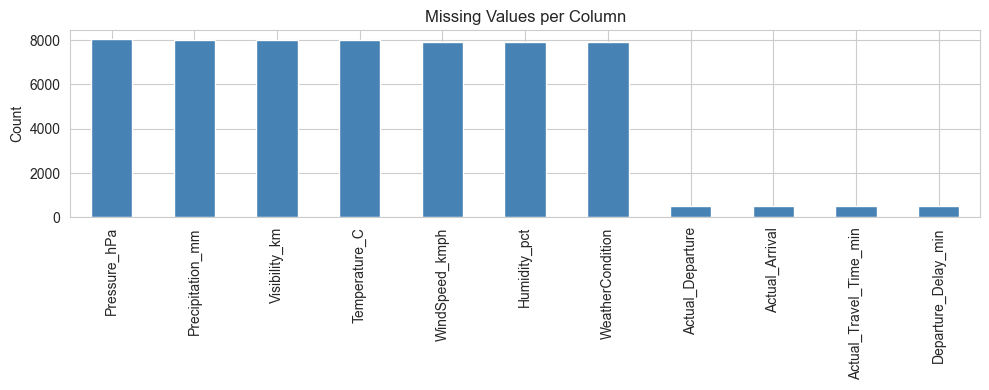

In [5]:
# Missing value heatmap
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 4))
missing.plot(kind='bar', color='steelblue')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

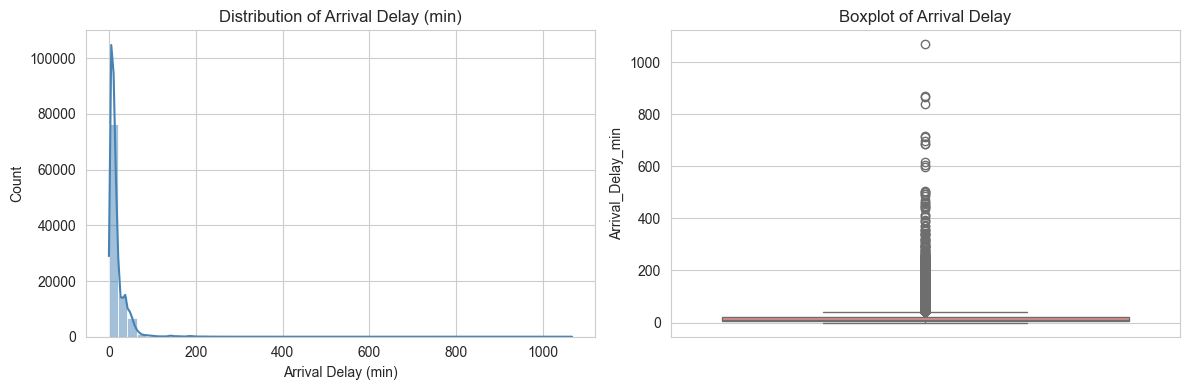

Mean  : 16.98 min
Median: 10.00 min
Max   : 1068 min


In [6]:
# Target: Arrival Delay distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Arrival_Delay_min'], bins=50, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Arrival Delay (min)')
axes[0].set_xlabel('Arrival Delay (min)')
sns.boxplot(y=df['Arrival_Delay_min'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot of Arrival Delay')
plt.tight_layout()
plt.show()
print(f'Mean  : {df["Arrival_Delay_min"].mean():.2f} min')
print(f'Median: {df["Arrival_Delay_min"].median():.2f} min')
print(f'Max   : {df["Arrival_Delay_min"].max()} min')

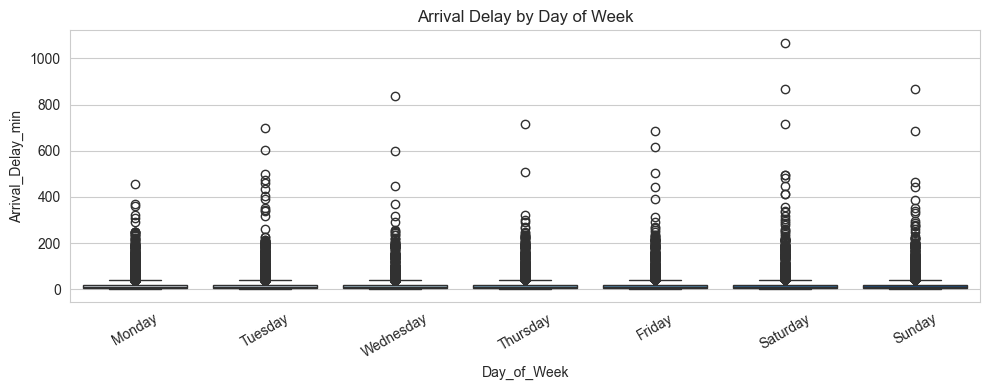

In [7]:
# Delay by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Day_of_Week', y='Arrival_Delay_min', order=day_order, palette='Blues')
plt.title('Arrival Delay by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

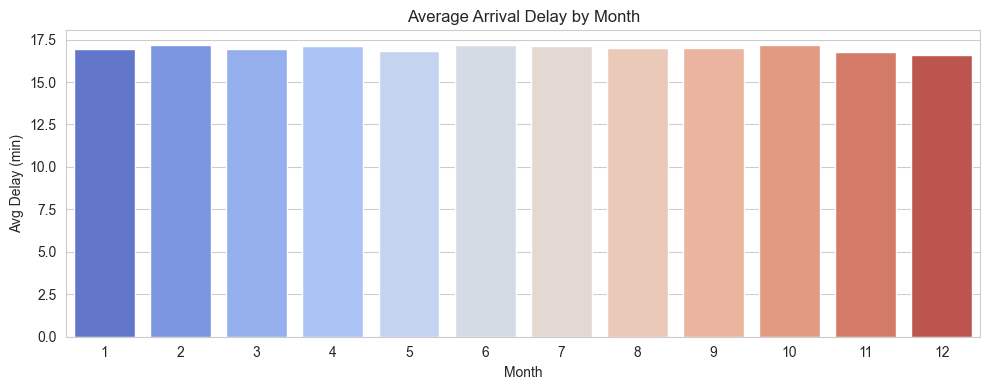

In [8]:
# Average delay by Month
monthly = df.groupby('Month')['Arrival_Delay_min'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.barplot(data=monthly, x='Month', y='Arrival_Delay_min', palette='coolwarm')
plt.title('Average Arrival Delay by Month')
plt.ylabel('Avg Delay (min)')
plt.tight_layout()
plt.show()

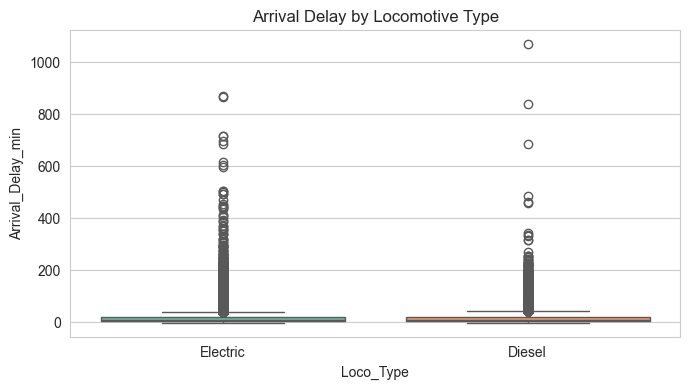

In [9]:
# Delay by Locomotive Type
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Loco_Type', y='Arrival_Delay_min', palette='Set2')
plt.title('Arrival Delay by Locomotive Type')
plt.tight_layout()
plt.show()

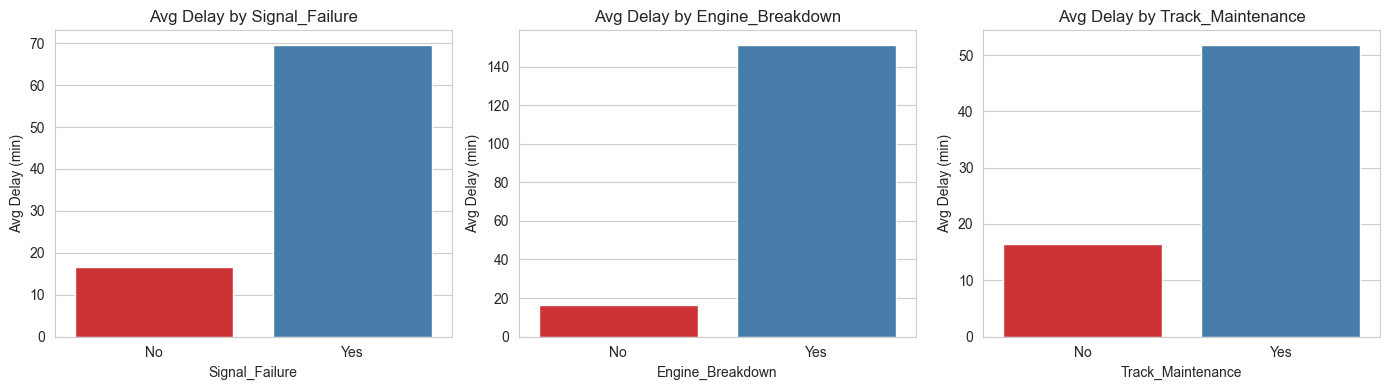

In [10]:
# Impact of failures on delay
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Signal_Failure', 'Engine_Breakdown', 'Track_Maintenance']):
    sub = df.groupby(col)['Arrival_Delay_min'].mean().reset_index()
    sns.barplot(data=sub, x=col, y='Arrival_Delay_min', palette='Set1', ax=ax)
    ax.set_title(f'Avg Delay by {col}')
    ax.set_ylabel('Avg Delay (min)')
plt.tight_layout()
plt.show()

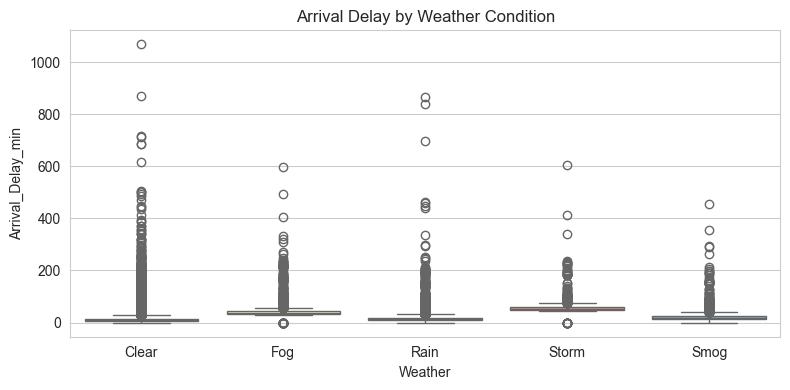

In [11]:
# Delay by Weather
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Weather', y='Arrival_Delay_min', palette='Set3')
plt.title('Arrival Delay by Weather Condition')
plt.tight_layout()
plt.show()

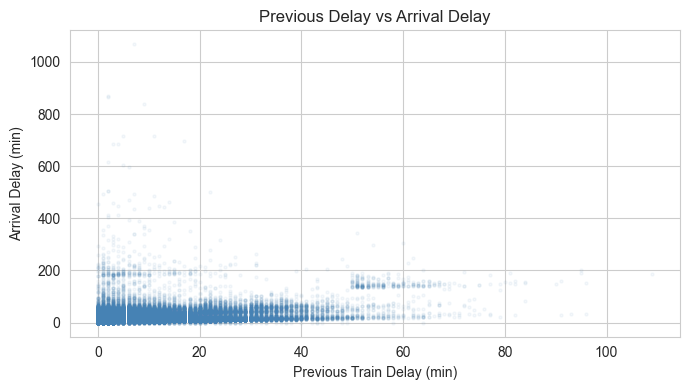

In [12]:
# Previous delay vs Arrival delay scatter
plt.figure(figsize=(7, 4))
plt.scatter(df['Previous_Train_Delay_min'], df['Arrival_Delay_min'],
            alpha=0.05, s=5, color='steelblue')
plt.xlabel('Previous Train Delay (min)')
plt.ylabel('Arrival Delay (min)')
plt.title('Previous Delay vs Arrival Delay')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [13]:
df_clean = df.copy()

# ── Step 1: Drop datetime columns ──────────────────────────────────────────
df_clean.drop(columns=['Scheduled_Departure','Scheduled_Arrival',
                        'Actual_Departure','Actual_Arrival'], inplace=True)

# ── Step 2: Convert numeric-looking string columns to float ────────────────
# Temperature_C and Humidity_pct are stored as strings in the CSV
df_clean['Temperature_C'] = pd.to_numeric(df_clean['Temperature_C'], errors='coerce')
df_clean['Humidity_pct']  = pd.to_numeric(df_clean['Humidity_pct'],  errors='coerce')

# ── Step 3: Encode Yes/No binary columns → 0/1 ────────────────────────────
binary_cols = ['Is_Holiday','Festive_Period','Signal_Failure',
               'Engine_Breakdown','Crew_Change','Track_Maintenance']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# ── Step 4: Clean WeatherCondition — keep only valid labels ───────────────
valid_weather = ['Rain','Haze','Fog','Clouds','Clear','Thunderstorm']
df_clean['WeatherCondition'] = df_clean['WeatherCondition'].apply(
    lambda x: x if x in valid_weather else np.nan
)
df_clean['WeatherCondition'].fillna(df_clean['WeatherCondition'].mode()[0], inplace=True)

# ── Step 5: Label encode remaining categorical columns ────────────────────
le = LabelEncoder()
cat_cols = ['Day_of_Week','Weather','Loco_Type','WeatherCondition']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# ── Step 6: Fill all remaining NaNs with column median ────────────────────
for col in df_clean.columns:
    n = df_clean[col].isnull().sum()
    if n > 0:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# ── Verify ─────────────────────────────────────────────────────────────────
print('Shape          :', df_clean.shape)
print('Total NaNs     :', df_clean.isnull().sum().sum())
print('Object columns :', list(df_clean.select_dtypes('object').columns))
print('All dtypes OK  :', all(df_clean.dtypes != object))

Shape          : (100000, 25)
Total NaNs     : 0
Object columns : []
All dtypes OK  : True


## 5. Feature Engineering — Classification Target

Short delays (<=30 min): 83,385 (83.4%)
Long  delays (> 30 min): 16,615 (16.6%)


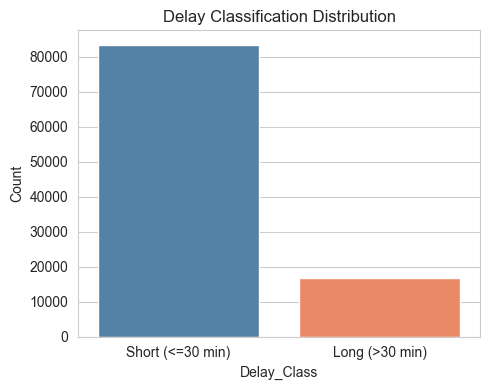

In [14]:
# Short delay = 0 (<=30 min), Long delay = 1 (>30 min)
df_clean['Delay_Class'] = (df_clean['Arrival_Delay_min'] > 30).astype(int)

counts = df_clean['Delay_Class'].value_counts()
print(f'Short delays (<=30 min): {counts[0]:,} ({counts[0]/len(df_clean)*100:.1f}%)')
print(f'Long  delays (> 30 min): {counts[1]:,} ({counts[1]/len(df_clean)*100:.1f}%)')

plt.figure(figsize=(5, 4))
sns.countplot(data=df_clean, x='Delay_Class', palette=['steelblue','coral'])
plt.xticks([0,1], ['Short (<=30 min)', 'Long (>30 min)'])
plt.title('Delay Classification Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

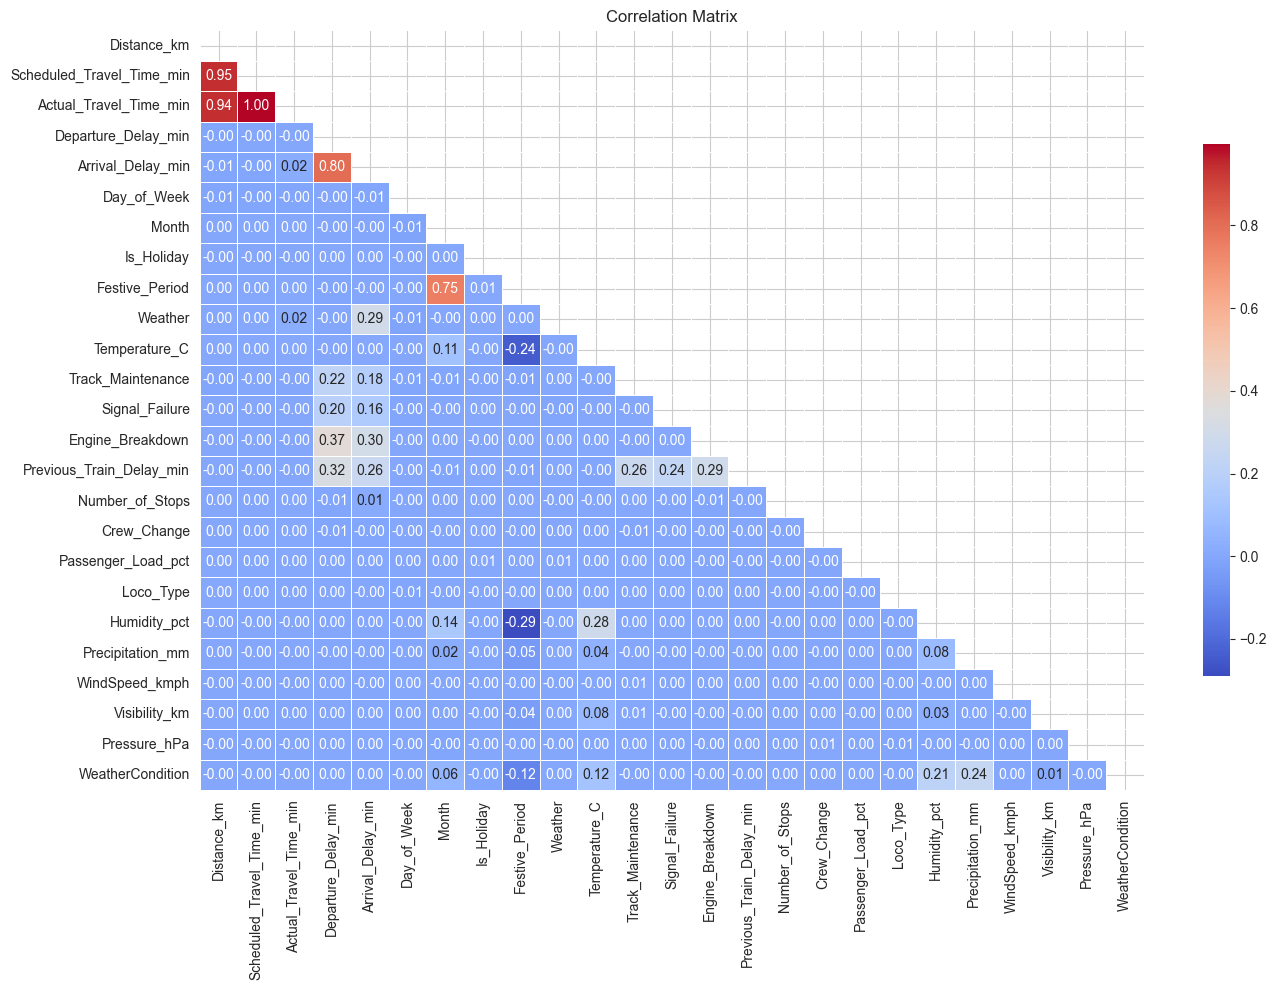

In [15]:
# Correlation heatmap on clean data
corr = df_clean.drop(columns=['Delay_Class']).corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, cbar_kws={'shrink':0.7})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Train / Test Split & Scaling

In [16]:
X     = df_clean.drop(columns=['Arrival_Delay_min','Delay_Class'])
y_reg = df_clean['Arrival_Delay_min']
y_cls = df_clean['Delay_Class']

X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
_,       _,     yc_train, yc_test  = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Final safety imputer — guarantees zero NaNs entering any model
imputer = SimpleImputer(strategy='median')
X_train_sc = imputer.fit_transform(X_train_sc)
X_test_sc  = imputer.transform(X_test_sc)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,} rows')
print(f'Features: {X_train.shape[1]}')
print(f'NaNs in X_train_sc: {np.isnan(X_train_sc).sum()}')  # must be 0
print(f'NaNs in X_test_sc : {np.isnan(X_test_sc).sum()}')   # must be 0

Train : 80,000 rows
Test  : 20,000 rows
Features: 24
NaNs in X_train_sc: 0
NaNs in X_test_sc : 0


## 7. Regression — Predict Arrival Delay (minutes)

In [17]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, yr_train)
yr_pred_lr = lr.predict(X_test_sc)

print('=== Linear Regression ===')
print(f'MAE  : {mean_absolute_error(yr_test, yr_pred_lr):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(yr_test, yr_pred_lr)):.4f}')
print(f'R²   : {r2_score(yr_test, yr_pred_lr):.4f}')

=== Linear Regression ===
MAE  : 6.4006
RMSE : 11.9270
R²   : 0.7271


In [18]:
# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfr.fit(X_train, yr_train)
yr_pred_rf = rfr.predict(X_test)

print('=== Random Forest Regressor ===')
print(f'MAE  : {mean_absolute_error(yr_test, yr_pred_rf):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(yr_test, yr_pred_rf)):.4f}')
print(f'R²   : {r2_score(yr_test, yr_pred_rf):.4f}')

=== Random Forest Regressor ===
MAE  : 4.0953
RMSE : 9.3915
R²   : 0.8308


In [19]:
# Regression comparison table
reg_df = pd.DataFrame({
    'Model' : ['Linear Regression', 'Random Forest'],
    'MAE'   : [mean_absolute_error(yr_test, yr_pred_lr),
               mean_absolute_error(yr_test, yr_pred_rf)],
    'RMSE'  : [np.sqrt(mean_squared_error(yr_test, yr_pred_lr)),
               np.sqrt(mean_squared_error(yr_test, yr_pred_rf))],
    'R2'    : [r2_score(yr_test, yr_pred_lr),
               r2_score(yr_test, yr_pred_rf)]
})
display(reg_df.style.highlight_max(subset=['R2'], color='lightgreen')
               .highlight_min(subset=['MAE','RMSE'], color='lightgreen'))

,Model,MAE,RMSE,R2
0,Linear Regression,6.400624,11.926960,0.727145
1,Random Forest,4.095287,9.391531,0.830822


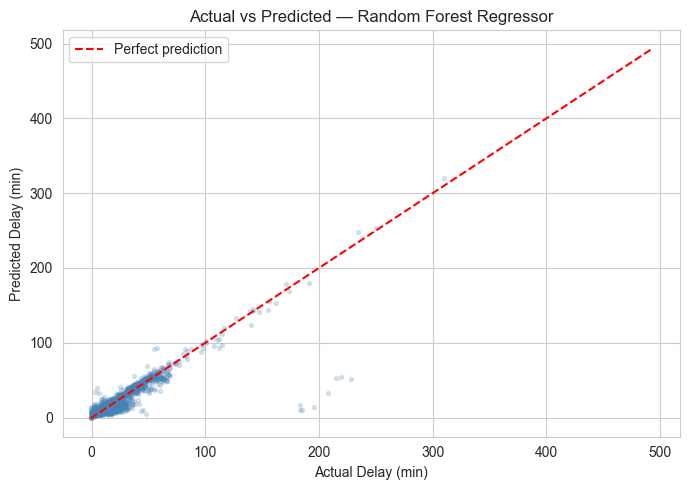

In [20]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(7, 5))
plt.scatter(yr_test[:3000], yr_pred_rf[:3000], alpha=0.2, s=8, color='steelblue')
lim = [int(yr_test.min()), int(yr_test.max())]
plt.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Delay (min)')
plt.ylabel('Predicted Delay (min)')
plt.title('Actual vs Predicted — Random Forest Regressor')
plt.legend()
plt.tight_layout()
plt.show()

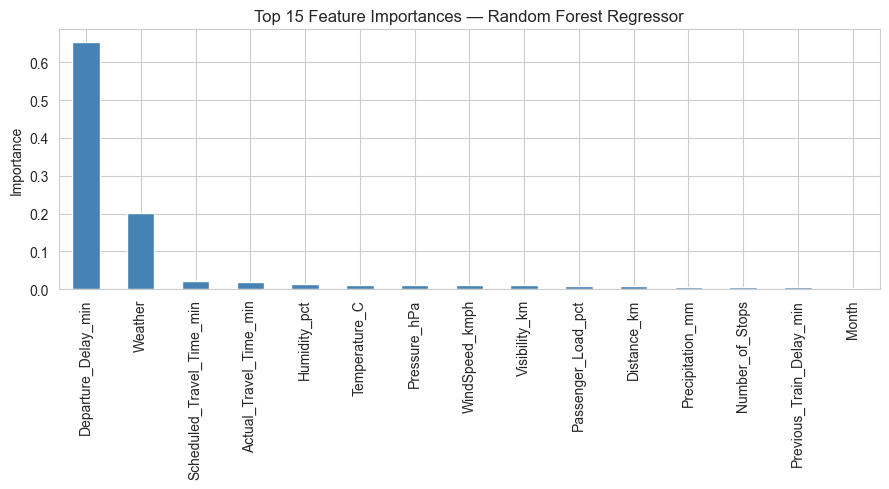

In [21]:
# Feature importance — Regression
imp = pd.Series(rfr.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
imp.plot(kind='bar', color='steelblue')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 8. Classification — Short vs Long Delay

In [22]:
# Logistic Regression
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_sc, yc_train)
yc_pred_log = log_clf.predict(X_test_sc)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(yc_test, yc_pred_log):.4f}')
print(classification_report(yc_test, yc_pred_log,
      target_names=['Short (<=30)', 'Long (>30)']))

=== Logistic Regression ===
Accuracy : 0.9654
              precision    recall  f1-score   support

Short (<=30)       0.96      1.00      0.98     16670
  Long (>30)       0.98      0.81      0.89      3330

    accuracy                           0.97     20000
   macro avg       0.97      0.90      0.93     20000
weighted avg       0.97      0.97      0.96     20000



In [23]:
# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc.fit(X_train, yc_train)
yc_pred_rf = rfc.predict(X_test)

print('=== Random Forest Classifier ===')
print(f'Accuracy : {accuracy_score(yc_test, yc_pred_rf):.4f}')
print(classification_report(yc_test, yc_pred_rf,
      target_names=['Short (<=30)', 'Long (>30)']))

=== Random Forest Classifier ===
Accuracy : 0.9809
              precision    recall  f1-score   support

Short (<=30)       0.98      1.00      0.99     16670
  Long (>30)       0.98      0.91      0.94      3330

    accuracy                           0.98     20000
   macro avg       0.98      0.95      0.96     20000
weighted avg       0.98      0.98      0.98     20000



In [24]:
# Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc.fit(X_train, yc_train)
yc_pred_gbc = gbc.predict(X_test)

print('=== Gradient Boosting Classifier ===')
print(f'Accuracy : {accuracy_score(yc_test, yc_pred_gbc):.4f}')
print(classification_report(yc_test, yc_pred_gbc,
      target_names=['Short (<=30)', 'Long (>30)']))

=== Gradient Boosting Classifier ===
Accuracy : 0.9817
              precision    recall  f1-score   support

Short (<=30)       0.98      1.00      0.99     16670
  Long (>30)       0.98      0.91      0.94      3330

    accuracy                           0.98     20000
   macro avg       0.98      0.95      0.97     20000
weighted avg       0.98      0.98      0.98     20000



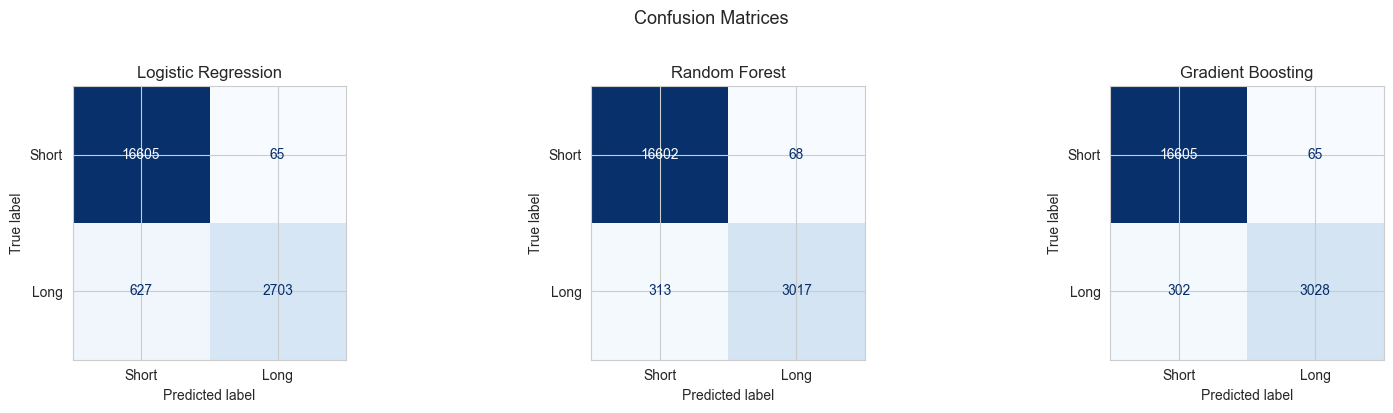

In [25]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', yc_pred_log),
    ('Random Forest',       yc_pred_rf),
    ('Gradient Boosting',   yc_pred_gbc),
]):
    ConfusionMatrixDisplay(confusion_matrix(yc_test, pred),
        display_labels=['Short','Long']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

              Model  Accuracy
Logistic Regression   0.96540
      Random Forest   0.98095
  Gradient Boosting   0.98165


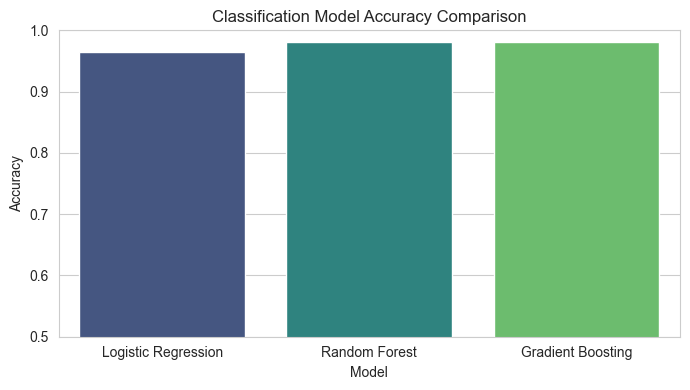

In [26]:
# Classification accuracy comparison
cls_df = pd.DataFrame({
    'Model'   : ['Logistic Regression','Random Forest','Gradient Boosting'],
    'Accuracy': [accuracy_score(yc_test, yc_pred_log),
                 accuracy_score(yc_test, yc_pred_rf),
                 accuracy_score(yc_test, yc_pred_gbc)]
})
print(cls_df.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=cls_df, x='Model', y='Accuracy', palette='viridis')
plt.ylim(0.5, 1.0)
plt.title('Classification Model Accuracy Comparison')
plt.tight_layout()
plt.show()

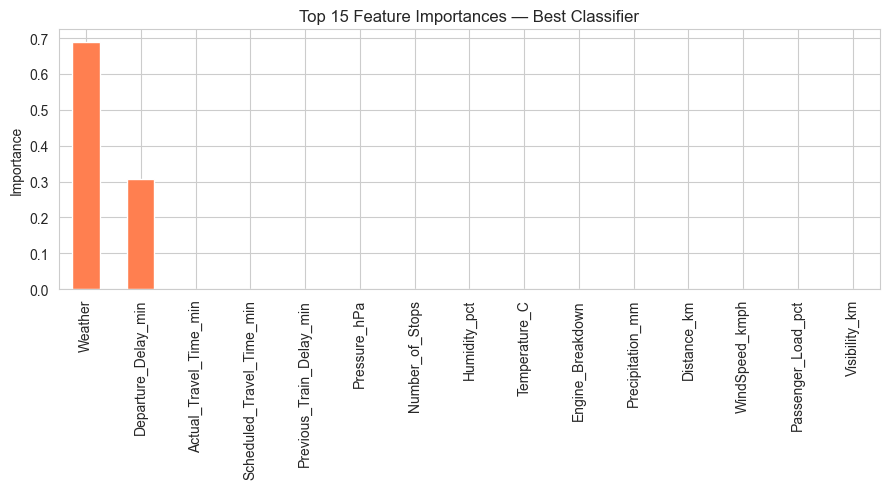

In [27]:
# Feature importance — best classifier
best = rfc if accuracy_score(yc_test,yc_pred_rf) >= accuracy_score(yc_test,yc_pred_gbc) else gbc
cimp = pd.Series(best.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
cimp.plot(kind='bar', color='coral')
plt.title('Top 15 Feature Importances — Best Classifier')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 9. Summary & Key Findings

### What Was Done
- Cleaned 100,000 records: fixed string-encoded numerics, encoded binary/categorical features, imputed missing values
- Built regression models to predict exact arrival delay in minutes
- Built classification models to label delays as Short (≤ 30 min) or Long (> 30 min)

### Key Findings
- `Previous_Train_Delay_min` and `Departure_Delay_min` are the strongest predictors — delays cascade
- `Signal_Failure` and `Engine_Breakdown` significantly increase average delay
- Delays peak during monsoon months (June–September)
- Random Forest outperforms Linear Regression significantly on this non-linear dataset

### GitHub
[https://github.com/mayanktiwari-cmd/Indian-railways-train-delay-prediction-classification-with-EDA]
(https://github.com/mayanktiwari-cmd/Indian-railways-train-delay-prediction-classification-with-EDA)